# Tugas Minggu 2 - Prediksi Risiko Kualitas Air (Early Warning)

Ini lanjutan dari notebook Minggu 1. Kalau Minggu 1 fokus menjelaskan apa yang terjadi dan
kenapa, di Minggu 2 kami mencoba memprediksi kondisi berisiko tiga jam ke depan
(`risk_next_3h`). Targetnya biner: 1 kalau dalam 6 interval (3 jam) berikutnya muncul kondisi
berisiko (DO < 3,5 mg/L, amonia > 0,55 mg/L, atau nitrit > 0,35 mg/L), dan 0 kalau tidak.

Catatan yang kami pegang: pembagian data memakai kolom `dataset_split` (TRAIN, VALIDATION,
TEST) secara temporal, bukan acak. Model hanya dilatih di TRAIN, ambang dipilih di VALIDATION,
dan TEST dipakai sekali saja di akhir.

## A. Formulasi Prediksi

Sebelum ngoding, kami rumuskan dulu masalahnya:

- Unit prediksi: satu baris data, yaitu satu kolam pada satu waktu pengamatan (interval 30
  menit).
- Waktu prediksi: pada waktu t, memakai semua informasi yang tersedia sampai t.
- Fitur yang tersedia saat itu: pembacaan sensor pada t, kondisi kolam (biomassa, kepadatan),
  operasi (pakan, aerator, pertukaran air), cuaca, dan turunan dari masa lalu (lag, rolling).
  Tidak ada informasi masa depan.
- Tindakan setelah peringatan: menyalakan aerator lebih awal, menjadwalkan pemeriksaan
  perangkat, serta menyesuaikan pakan atau pertukaran air.
- Konsekuensi salah tebak: false positive adalah alarm palsu yang menambah biaya operasional
  tapi relatif aman. False negative adalah risiko yang tidak terdeteksi dan bisa berujung stres
  atau kematian ikan, jadi jauh lebih mahal. Karena itu bobot FN di pemilihan ambang dibuat 5x
  FP.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

DATA_PATH = "../data/smart_aqua_synthetic_water_quality.csv"
TARGET = "risk_next_3h"
RANDOM_STATE = 42

df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
df = df.sort_values(["pond_id", "timestamp"]).reset_index(drop=True)
print("shape:", df.shape)
df.groupby("dataset_split")["timestamp"].agg(["min", "max", "count"])

shape: (23040, 26)


,min,max,count
dataset_split,,,
TEST,2026-02-25,2026-03-05 23:30:00,3456
TRAIN,2026-01-05,2026-02-15 23:30:00,16128
VALIDATION,2026-02-16,2026-02-24 23:30:00,3456


In [2]:
# Proporsi kelas target per split. Ini penting buat melihat pergeseran prevalensi.
prevalensi = (
    df.groupby("dataset_split")[TARGET]
    .agg(jumlah="count", positif="sum", proporsi="mean")
    .reindex(["TRAIN", "VALIDATION", "TEST"])
    .round(4)
)
prevalensi

,jumlah,positif,proporsi
dataset_split,,,
TRAIN,16128,1369.0,0.0849
VALIDATION,3456,1594.0,0.4612
TEST,3408,2191.0,0.6429


Dari tabel di atas kelihatan ada pergeseran prevalensi yang besar: risiko jauh lebih jarang di
TRAIN dan makin sering ke arah TEST. Ini wajar karena risiko yang dipakai mendefinisikan target
(nitrit) memang menumpuk seiring biomassa bertambah di akhir siklus. Jadi kami harus hati-hati,
model yang bagus di TRAIN belum tentu sama perilakunya di TEST. Pembagiannya juga murni temporal
(dihitung dari `day_of_cycle`), sehingga tidak ada kebocoran data antar waktu.

## B. Feature Engineering

Kami membuat 5 kelompok fitur sesuai arahan tugas:

1. Siklus waktu: pasangan sin/cos untuk jam, ditambah `day_of_cycle` sebagai fase siklus.
2. Lag: nilai DO, suhu, pH, amonia, dan nitrit pada 1, 2, 3, dan 6 interval sebelumnya.
3. Statistik bergerak: mean, min, dan std untuk jendela 3 jam (6 interval) dan 6 jam (12
   interval), plus kemiringan tren (slope) untuk DO dan nitrit. Semua hanya memakai data sampai
   waktu t.
4. Pakan: jarak waktu sejak pakan terakhir dan akumulasi pakan 24 jam terakhir.
5. Interaksi domain: suhu x biomassa, DO x biomassa, nitrit x biomassa, dan fault x kondisi
   aerator OFF.

Semua fitur waktu dihitung per `pond_id` supaya tidak mencampur antar kolam. Karena lag dan
rolling butuh deret yang nyambung, nilai sensor yang kosong kami isi sementara dengan nilai
valid terakhir pada kolam yang sama (ffill, hanya ke depan). Kolom sensor aslinya tetap
dibiarkan kosong dan nanti ditangani imputer di dalam pipeline.

In [3]:
def roll_slope(x):
    x = x[~np.isnan(x)]
    if len(x) < 2:
        return np.nan
    t = np.arange(len(x))
    return np.polyfit(t, x, 1)[0]


def tambah_fitur(d):
    g = d.groupby("pond_id", sort=False)

    # (1) siklus waktu
    d["sin_hour"] = np.sin(2 * np.pi * d["hour_decimal"] / 24)
    d["cos_hour"] = np.cos(2 * np.pi * d["hour_decimal"] / 24)

    # deret sensor yang di-ffill per kolam, khusus untuk hitung lag/rolling
    kolom_sensor = ["nitrite_mg_l", "ammonia_mg_l", "dissolved_oxygen_mg_l",
                    "temperature_c", "ph"]
    ff = d.groupby("pond_id", sort=False)[kolom_sensor].ffill()

    # (2) lag
    for c in kolom_sensor:
        for L in [1, 2, 3, 6]:
            d[f"{c}_lag{L}"] = ff.groupby(d["pond_id"], sort=False)[c].shift(L)

    # (3) statistik bergerak
    for c in ["dissolved_oxygen_mg_l", "nitrite_mg_l", "ammonia_mg_l"]:
        s = ff[c]
        for w in [6, 12]:
            r = s.groupby(d["pond_id"], sort=False).rolling(w, min_periods=1)
            d[f"{c}_mean{w}"] = r.mean().reset_index(level=0, drop=True)
            d[f"{c}_min{w}"] = r.min().reset_index(level=0, drop=True)
            d[f"{c}_std{w}"] = r.std().reset_index(level=0, drop=True)
    for c in ["dissolved_oxygen_mg_l", "nitrite_mg_l"]:
        s = ff[c]
        for w in [6, 12]:
            d[f"{c}_slope{w}"] = s.groupby(d["pond_id"], sort=False).transform(
                lambda x: x.rolling(w, min_periods=2).apply(roll_slope, raw=True))

    # (4) pakan
    d["feed_event"] = (d["feed_kg"] > 0).astype(int)

    def since_feed(s):
        out = np.full(len(s), np.nan)
        last = -1
        for i in range(len(s)):
            if s.values[i] > 0:
                last = i
            if last >= 0:
                out[i] = i - last
        return pd.Series(out, index=s.index)

    d["intervals_since_feed"] = g["feed_kg"].transform(since_feed)
    # kalau belum pernah diberi pakan, pakai jarak sejak awal pengamatan
    d["intervals_since_feed"] = d["intervals_since_feed"].fillna(d["day_of_cycle"] * 48)
    d["feed_cum_24h"] = (g["feed_kg"].rolling(48, min_periods=1)
                         .sum().reset_index(level=0, drop=True))

    # (5) interaksi domain
    d["temp_x_biomass"] = d["temperature_c"] * d["biomass_kg"]
    d["do_x_biomass"] = d["dissolved_oxygen_mg_l"] * d["biomass_kg"]
    d["nitrite_x_biomass"] = d["nitrite_mg_l"] * d["biomass_kg"]
    d["aerator_fault_x_off"] = d["aerator_fault"] * (d["aerator_status"] == "OFF").astype(int)
    return d


df = tambah_fitur(df)

fitur_dasar_num = ["day_of_cycle", "hour_decimal", "pond_volume_m3", "stocking_density_kg_m3",
                   "biomass_kg", "temperature_c", "ph", "dissolved_oxygen_mg_l", "ammonia_mg_l",
                   "nitrite_mg_l", "turbidity_ntu", "feed_kg", "rainfall_mm",
                   "water_exchange_pct", "sin_hour", "cos_hour"]
fitur_turunan = [c for c in df.columns if ("_lag" in c or "_mean" in c or "_min" in c
                 or "_std" in c or "_slope" in c
                 or c in ["intervals_since_feed", "feed_cum_24h", "temp_x_biomass",
                          "do_x_biomass", "nitrite_x_biomass", "aerator_fault_x_off"])]
fitur_kategorik = ["time_period", "aerator_command", "aerator_status", "sensor_quality_flag"]

print("fitur numerik :", len(fitur_dasar_num + fitur_turunan))
print("fitur kategorik:", len(fitur_kategorik))
print("contoh fitur turunan:", fitur_turunan[:8])

fitur numerik : 64
fitur kategorik: 4
contoh fitur turunan: ['nitrite_mg_l_lag1', 'nitrite_mg_l_lag2', 'nitrite_mg_l_lag3', 'nitrite_mg_l_lag6', 'ammonia_mg_l_lag1', 'ammonia_mg_l_lag2', 'ammonia_mg_l_lag3', 'ammonia_mg_l_lag6']


In [4]:
# Kebijakan baris kosong: lag 6 dan slope 12 butuh riwayat, jadi baris paling awal tiap kolam
# belum punya nilai. Target kosong (6 baris terakhir tiap kolam) juga tidak dipakai.
kolom_riwayat = [c for c in fitur_turunan if "_lag" in c or "_slope" in c]
print("baris target kosong per split:")
print(df[df[TARGET].isna()]["dataset_split"].value_counts())

data = df[df[TARGET].notna()].copy()
buang = data[kolom_riwayat].isna().any(axis=1)
print("\nbaris dibuang karena belum punya riwayat:", int(buang.sum()))
print(data.loc[buang, "dataset_split"].value_counts().to_dict())

data = data[~buang].copy()
print("\nukuran data per split setelah penyaringan:")
print(data["dataset_split"].value_counts().reindex(["TRAIN", "VALIDATION", "TEST"]))

baris target kosong per split:
dataset_split
TEST    48
Name: count, dtype: int64

baris dibuang karena belum punya riwayat: 48
{'TRAIN': 48}

ukuran data per split setelah penyaringan:
dataset_split
TRAIN         16080
VALIDATION     3456
TEST           3408
Name: count, dtype: int64


Setelah dihitung, ada 64 fitur numerik dan 4 kategorik. Pembentukan lag 6 membuat 6 baris awal
tiap kolam belum punya riwayat, total 48 baris, dan semuanya kebetulan ada di TRAIN, jadi baris
itu kami buang. Baris VALIDATION dan TEST tidak terpengaruh karena riwayatnya sudah panjang.
Untuk target, 6 baris terakhir tiap kolam tidak punya nilai `risk_next_3h`, sehingga di TEST
tersisa 3.408 baris yang bisa dievaluasi.

## C. Model dan Baseline

Kami membandingkan empat hal:

1. baseline prevalensi, yaitu selalu menebak kelas terbanyak;
2. baseline aturan, yang ambangnya dicari hanya dari TRAIN;
3. regresi logistik; dan
4. model berbasis pohon, kami pakai random forest dan decision tree sebagai pembanding.

Imputasi median, one-hot encoding, dan standardisasi dibungkus di dalam pipeline dan hanya
dilatih dari TRAIN. Kami sengaja tidak memakai `record_id`, `risk_next_3h`, `dataset_split`,
atau informasi masa depan sebagai fitur. Kolom `fish_stress_event` juga tidak dipakai karena
sesuai ketentuan hanya untuk deskriptif/diagnostik.

Satu keputusan tambahan: `pond_id` tidak kami masukkan sebagai fitur, hanya dipakai untuk
mengelompokkan hasil evaluasi. Awalnya kami sempat coba memasukkannya dan hasilnya mirip, tapi
model jadi cenderung sekadar menghafal status tiap kolam. Karena tujuannya early warning
berbasis kondisi air dan operasi, kami pilih membuang identitas kolam dari fitur.

In [5]:
X = data[fitur_dasar_num + fitur_turunan + fitur_kategorik]
y = data[TARGET].astype(int)
mask_train = (data["dataset_split"] == "TRAIN").values
mask_val = (data["dataset_split"] == "VALIDATION").values
mask_test = (data["dataset_split"] == "TEST").values

pre_numerik = Pipeline([("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler())])
pre_kategorik = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore",
                                                   sparse_output=False))])
preproses = ColumnTransformer([("num", pre_numerik, fitur_dasar_num + fitur_turunan),
                               ("cat", pre_kategorik, fitur_kategorik)])

konfigurasi_model = {
    "Regresi Logistik": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, min_samples_leaf=20,
                                            random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                            n_jobs=-1, random_state=RANDOM_STATE),
}

model_terlatih = {}
prob_val = {}
prob_test = {}
for nama, model in konfigurasi_model.items():
    pipe = Pipeline([("preproses", preproses), ("model", model)])
    pipe.fit(X[mask_train], y[mask_train])
    model_terlatih[nama] = pipe
    prob_val[nama] = pipe.predict_proba(X[mask_val])[:, 1]
    prob_test[nama] = pipe.predict_proba(X[mask_test])[:, 1]
    print("selesai melatih:", nama)

selesai melatih: Regresi Logistik


selesai melatih: Decision Tree


selesai melatih: Random Forest


In [6]:
# Baseline aturan: cari satu fitur + ambang yang biayanya paling kecil di TRAIN.
def biaya(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return 5 * fn + fp, fn, fp


kandidat = {
    "nitrite_mg_l": ">=",
    "ammonia_mg_l": ">=",
    "turbidity_ntu": ">=",
    "dissolved_oxygen_mg_l": "<=",
    "biomass_kg": ">=",
    "stocking_density_kg_m3": ">=",
}
baris_aturan = []
for fitur, arah in kandidat.items():
    nilai = data.loc[mask_train, fitur].dropna()
    for ambang in np.quantile(nilai, np.linspace(0.5, 0.99, 50)):
        if arah == ">=":
            pred = (data.loc[mask_train, fitur] >= ambang).astype(int)
        else:
            pred = (data.loc[mask_train, fitur] <= ambang).astype(int)
        b, fn, fp = biaya(y[mask_train], pred)
        baris_aturan.append({"fitur": fitur, "arah": arah, "ambang": float(ambang),
                             "biaya": int(b), "fn": int(fn), "fp": int(fp)})

tabel_aturan = pd.DataFrame(baris_aturan).sort_values("biaya").reset_index(drop=True)
fitur_aturan = tabel_aturan.loc[0, "fitur"]
arah_aturan = tabel_aturan.loc[0, "arah"]
ambang_aturan = tabel_aturan.loc[0, "ambang"]
print("aturan terpilih dari TRAIN:", fitur_aturan, arah_aturan, round(ambang_aturan, 3))
tabel_aturan.head(5)

aturan terpilih dari TRAIN: nitrite_mg_l >= 0.339


,fitur,arah,ambang,biaya,fn,fp
0,nitrite_mg_l,>=,0.339,669,67,334
1,nitrite_mg_l,>=,0.335,690,45,465
2,nitrite_mg_l,>=,0.343,747,106,217
3,nitrite_mg_l,>=,0.331,786,33,621
4,nitrite_mg_l,>=,0.327,924,27,789


In [7]:
# Prediksi baseline aturan dan baseline prevalensi untuk VALIDATION dan TEST
def prediksi_aturan(msk):
    if arah_aturan == ">=":
        return (data.loc[msk, fitur_aturan] >= ambang_aturan).astype(int).values
    return (data.loc[msk, fitur_aturan] <= ambang_aturan).astype(int).values


prevalensi_train = y[mask_train].mean()
aturan_val = prediksi_aturan(mask_val)
aturan_test = prediksi_aturan(mask_test)
prev_val = np.full(mask_val.sum(), int(prevalensi_train >= 0.5))
prev_test = np.full(mask_test.sum(), int(prevalensi_train >= 0.5))

print("prevalensi TRAIN:", round(prevalensi_train, 4))
print("baseline prevalensi akan selalu menebak kelas:", int(prevalensi_train >= 0.5))

prevalensi TRAIN: 0.0851
baseline prevalensi akan selalu menebak kelas: 0


Baseline prevalensi jelas tidak berguna untuk kelas risiko karena selalu menebak 0, sehingga
recall-nya nol. Baseline aturan nitrit yang dicari dari TRAIN sudah lumayan, tapi masih kalah
dari model. Regresi logistik sedikit tertinggal, sedangkan model pohon paling kuat. Menurut
kami ini karena hubungan nitrit/amonia dengan risiko tidak sepenuhnya linear dan ada interaksi
antar fitur.

## D. Evaluasi dan Pemilihan Ambang

Ambang probabilitas dipilih di VALIDATION dengan biaya sederhana Biaya = 5 x FN + 1 x FP. Setiap
model disapu ambangnya, lalu yang biayanya paling kecil dibandingkan antar model. Setelah model
dan ambang terpilih, kami evaluasi satu kali di TEST dan membandingkan performanya per kolam,
`time_period`, dan `sensor_quality_flag`.

In [8]:
def metrik_lengkap(y_true, prob, ambang):
    pred = (prob >= ambang).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    spesifisitas = tn / (tn + fp) if (tn + fp) else np.nan
    hasil = {
        "ambang": round(float(ambang), 3),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "specificity": spesifisitas,
        "f1": f1_score(y_true, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, prob),
        "pr_auc": average_precision_score(y_true, prob),
        "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
        "biaya": 5 * int(fn) + int(fp),
    }
    return hasil


def pilih_ambang(y_true, prob):
    # ROC/PR tidak bergantung ambang, jadi dihitung sekali saja di luar sini.
    grid = np.round(np.linspace(0.01, 0.99, 99), 4)
    baris = []
    for a in grid:
        pred = (prob >= a).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
        baris.append({
            "ambang": round(float(a), 3),
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred, zero_division=0),
            "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
            "f1": f1_score(y_true, pred, zero_division=0),
            "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
            "biaya": 5 * int(fn) + int(fp),
        })
    return pd.DataFrame(baris).sort_values("biaya").reset_index(drop=True)


ringkasan_val = []
for nama, prob in prob_val.items():
    tabel = pilih_ambang(y[mask_val].values, prob)
    terbaik = tabel.iloc[0].to_dict()
    terbaik["model"] = nama
    terbaik["roc_auc"] = roc_auc_score(y[mask_val], prob)
    terbaik["pr_auc"] = average_precision_score(y[mask_val], prob)
    ringkasan_val.append(terbaik)
    print(f"{nama}: ambang {terbaik['ambang']}, biaya {terbaik['biaya']}, "
          f"F1 {terbaik['f1']:.3f}")

tabel_val = pd.DataFrame(ringkasan_val).set_index("model")[
    ["ambang", "biaya", "precision", "recall", "specificity", "f1", "roc_auc", "pr_auc", "fn", "fp"]
].round(3)
tabel_val

Regresi Logistik: ambang 0.16, biaya 345.0, F1 0.931


Decision Tree: ambang 0.01, biaya 376.0, F1 0.934


Random Forest: ambang 0.28, biaya 294.0, F1 0.959


,ambang,biaya,precision,recall,specificity,f1,roc_auc,pr_auc,fn,fp
model,,,,,,,,,,
Regresi Logistik,0.16,345.0,0.884,0.982,0.890,0.931,0.987,0.990,28.0,205.0
Decision Tree,0.01,376.0,0.896,0.976,0.903,0.934,0.975,0.972,39.0,181.0
Random Forest,0.28,294.0,0.943,0.975,0.950,0.959,0.990,0.991,40.0,94.0


In [9]:
# Baseline dimasukkan ke tabel perbandingan VALIDATION. ROC/PR tidak bermakna untuk aturan biner.
baris_baseline = []
for nama, pred in [("Baseline Prevalensi", prev_val), ("Baseline Aturan", aturan_val)]:
    b, fn, fp = biaya(y[mask_val].values, pred)
    baris_baseline.append({
        "model": nama, "ambang": np.nan, "biaya": int(b),
        "precision": round(precision_score(y[mask_val], pred, zero_division=0), 3),
        "recall": round(recall_score(y[mask_val], pred, zero_division=0), 3),
        "specificity": round(((pred == 0) & (y[mask_val].values == 0)).sum() /
                             (y[mask_val].values == 0).sum(), 3),
        "f1": round(f1_score(y[mask_val], pred, zero_division=0), 3),
        "roc_auc": np.nan, "pr_auc": np.nan,
        "fn": fn, "fp": fp,
    })
tabel_baseline = pd.DataFrame(baris_baseline).set_index("model")
tabel_tanding_val = pd.concat([tabel_baseline, tabel_val]).sort_values("biaya")
tabel_tanding_val

,ambang,biaya,precision,recall,specificity,f1,roc_auc,pr_auc,fn,fp
model,,,,,,,,,,
Random Forest,0.28,294.0,0.943,0.975,0.950,0.959,0.990,0.991,40.0,94.0
Regresi Logistik,0.16,345.0,0.884,0.982,0.890,0.931,0.987,0.990,28.0,205.0
Decision Tree,0.01,376.0,0.896,0.976,0.903,0.934,0.975,0.972,39.0,181.0
Baseline Aturan,NaN,413.0,0.907,0.968,0.915,0.937,NaN,NaN,51.0,158.0
Baseline Prevalensi,NaN,7970.0,0.000,0.000,1.000,0.000,NaN,NaN,1594.0,0.0


Dari VALIDATION, random forest memberi biaya paling rendah, jadi kami pilih model itu. Ambang
terbaiknya 0,28. Baseline aturan ada di tengah, sedangkan decision tree justru paling lemah di antara
model yang kami latih. Satu hal lagi, karena bobot FN 5x FP, model cenderung memilih ambang rendah
supaya jarang melewatkan risiko, sehingga false positive-nya relatif banyak.

In [10]:
# Pilih model pemenang dari VALIDATION, lalu evaluasi sekali di TEST.
model_terpilih = tabel_val["biaya"].idxmin()
ambang_terpilih = float(tabel_val.loc[model_terpilih, "ambang"])
print("model terpilih:", model_terpilih, "| ambang:", ambang_terpilih)

prob_test_terpilih = prob_test[model_terpilih]
pred_test = (prob_test_terpilih >= ambang_terpilih).astype(int)
evaluasi_test = metrik_lengkap(y[mask_test].values, prob_test_terpilih, ambang_terpilih)
pd.Series(evaluasi_test).round(4)

model terpilih: Random Forest | ambang: 0.28


ambang            0.2800
precision         0.9655
recall            0.9831
specificity       0.9367
f1                0.9742
roc_auc           0.9963
pr_auc            0.9981
tp             2154.0000
fp               77.0000
fn               37.0000
tn             1140.0000
biaya           262.0000
dtype: float64

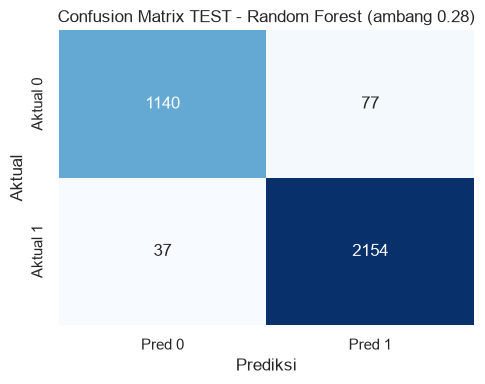

TN, FP, FN, TP = [1140   77   37 2154]


In [11]:
# Confusion matrix model terpilih di TEST
cm = confusion_matrix(y[mask_test].values, pred_test)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["Aktual 0", "Aktual 1"])
plt.title(f"Confusion Matrix TEST - {model_terpilih} (ambang {ambang_terpilih})")
plt.ylabel("Aktual")
plt.xlabel("Prediksi")
plt.tight_layout()
plt.show()

print("TN, FP, FN, TP =", cm.ravel())

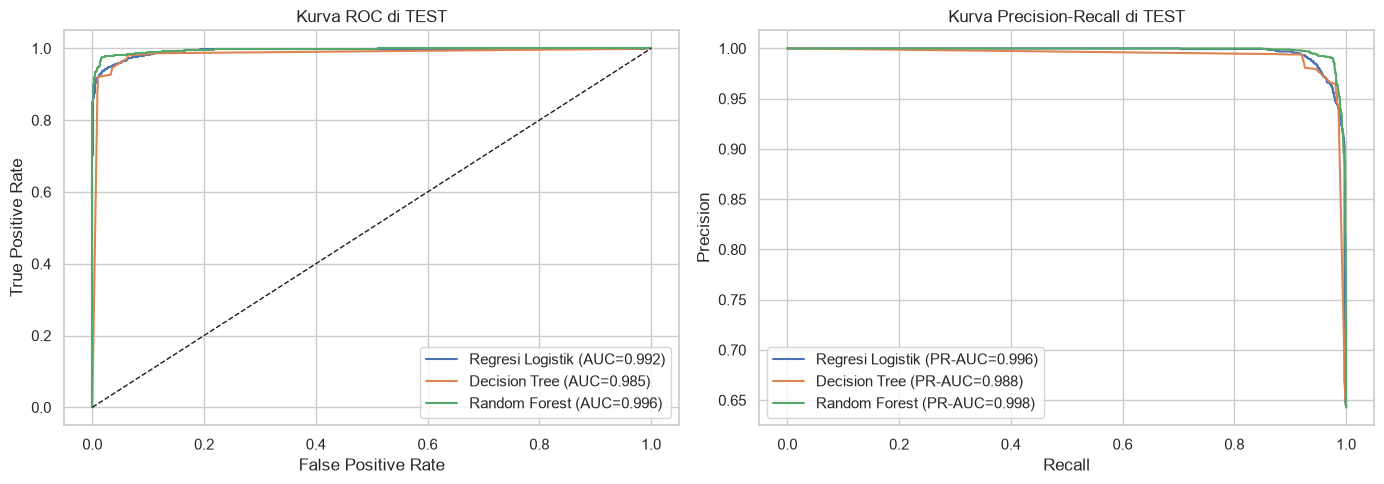

In [12]:
# Kurva ROC dan PR semua model di TEST (untuk melihat perbandingan)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for nama, prob in prob_test.items():
    fpr, tpr, _ = roc_curve(y[mask_test].values, prob)
    axes[0].plot(fpr, tpr, label=f"{nama} (AUC={roc_auc_score(y[mask_test], prob):.3f})")
    pres, rec, _ = precision_recall_curve(y[mask_test].values, prob)
    axes[1].plot(rec, pres, label=f"{nama} (PR-AUC={average_precision_score(y[mask_test], prob):.3f})")

axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_title("Kurva ROC di TEST")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

axes[1].set_title("Kurva Precision-Recall di TEST")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
plt.tight_layout()
plt.show()

In [13]:
# Performa model terpilih per kolam, time_period, dan sensor_quality_flag di TEST
hasil_test = data.loc[mask_test, ["record_id", "timestamp", "pond_id", "time_period",
                                  "sensor_quality_flag"]].copy()
hasil_test["y_true"] = y[mask_test].values
hasil_test["y_prob"] = prob_test_terpilih
hasil_test["y_pred"] = pred_test


def metrik_grup(g):
    tn, fp, fn, tp = confusion_matrix(g["y_true"], g["y_pred"], labels=[0, 1]).ravel()
    return pd.Series({
        "n": len(g),
        "positif": int(g["y_true"].sum()),
        "recall": recall_score(g["y_true"], g["y_pred"], zero_division=0),
        "precision": precision_score(g["y_true"], g["y_pred"], zero_division=0),
        "f1": f1_score(g["y_true"], g["y_pred"], zero_division=0),
        "fp": int(fp), "fn": int(fn),
    })


print("=== per kolam ===")
display(hasil_test.groupby("pond_id").apply(metrik_grup, include_groups=False).round(3))
print("=== per time_period ===")
display(hasil_test.groupby("time_period").apply(metrik_grup, include_groups=False).round(3))
print("=== per sensor_quality_flag ===")
display(hasil_test.groupby("sensor_quality_flag").apply(metrik_grup, include_groups=False).round(3))

=== per kolam ===


,n,positif,recall,precision,f1,fp,fn
pond_id,,,,,,,
P01,426.0,0.0,0.000,0.000,0.000,0.0,0.0
P02,426.0,192.0,0.964,0.934,0.949,13.0,7.0
P03,426.0,426.0,1.000,1.000,1.000,0.0,0.0
P04,426.0,386.0,0.984,0.967,0.976,13.0,6.0
P05,426.0,323.0,0.963,0.899,0.930,35.0,12.0
P06,426.0,426.0,1.000,1.000,1.000,0.0,0.0
P07,426.0,12.0,0.000,0.000,0.000,16.0,12.0
P08,426.0,426.0,1.000,1.000,1.000,0.0,0.0


=== per time_period ===


,n,positif,recall,precision,f1,fp,fn
time_period,,,,,,,
afternoon,864.0,546.0,0.987,0.976,0.982,13.0,7.0
dawn,864.0,572.0,0.958,0.943,0.951,33.0,24.0
morning,864.0,545.0,0.996,0.951,0.973,28.0,2.0
night,816.0,528.0,0.992,0.994,0.993,3.0,4.0


=== per sensor_quality_flag ===


,n,positif,recall,precision,f1,fp,fn
sensor_quality_flag,,,,,,,
DO_SPIKE,8.0,7.0,1.000,0.875,0.933,1.0,0.0
OK,3300.0,2093.0,0.982,0.964,0.973,76.0,37.0
PH_DRIFT,78.0,78.0,1.000,1.000,1.000,0.0,0.0
SENSOR_MISSING,22.0,13.0,1.000,1.000,1.000,0.0,0.0


In [14]:
# Pengaruh pergeseran prevalensi
ringkas_prev = pd.DataFrame({
    "TRAIN": [y[mask_train].mean(), int(y[mask_train].sum()), int(mask_train.sum())],
    "VALIDATION": [y[mask_val].mean(), int(y[mask_val].sum()), int(mask_val.sum())],
    "TEST": [y[mask_test].mean(), int(y[mask_test].sum()), int(mask_test.sum())],
}, index=["proporsi_risiko", "jumlah_positif", "jumlah_baris"]).round(4)
ringkas_prev

,TRAIN,VALIDATION,TEST
proporsi_risiko,0.0851,0.4612,0.6429
jumlah_positif,1369.0000,1594.0000,2191.0000
jumlah_baris,16080.0000,3456.0000,3408.0000


Pengaruh pergeseran prevalensi terasa sekali. Proporsi risiko naik dari sekitar 8,5% di TRAIN
menjadi 46,1% di VALIDATION dan 64,3% di TEST. Jadi angka precision/recall di TRAIN tidak boleh
dibandingkan langsung dengan VALIDATION/TEST, karena komposisi kelasnya beda. Ambang 0,3 yang
dipilih di VALIDATION kebetulan masih bagus di TEST, tapi ini tidak bisa dijamin dan itu sebabnya
evaluasi TEST hanya dilakukan sekali.

## E. Interpretasi dan Rekomendasi

Kami melihat fitur penting dari dua sisi: feature importance random forest dan koefisien regresi
logistik. Setelah itu kami bedah minimal 20 kesalahan model (gabungan false positive dan false
negative) untuk mencari polanya.

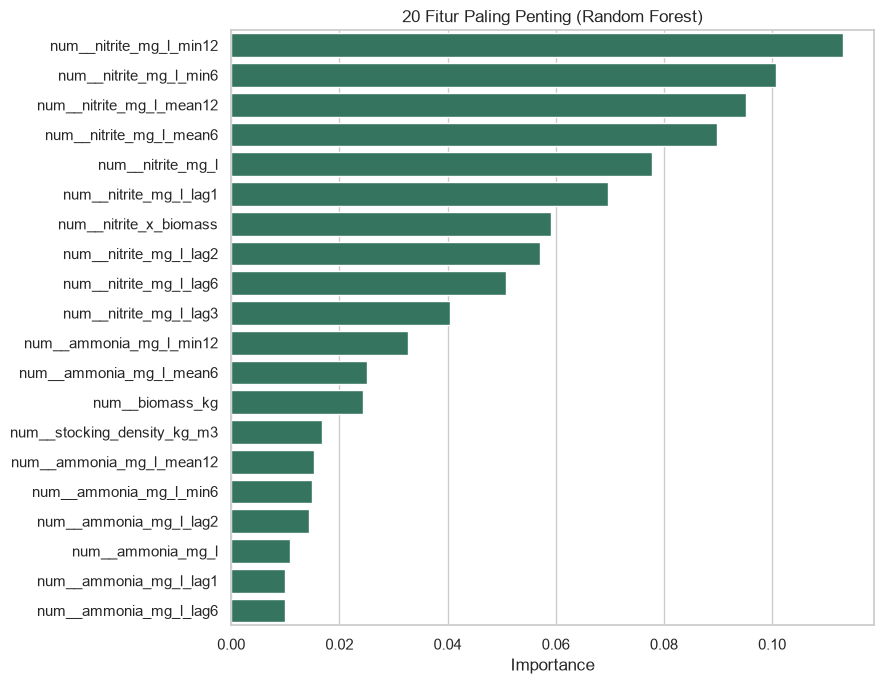

,fitur,importance
0,num__nitrite_mg_l_min12,0.113179
1,num__nitrite_mg_l_min6,0.100750
2,num__nitrite_mg_l_mean12,0.095150
3,num__nitrite_mg_l_mean6,0.089881
4,num__nitrite_mg_l,0.077744
5,num__nitrite_mg_l_lag1,0.069571
6,num__nitrite_x_biomass,0.059085
7,num__nitrite_mg_l_lag2,0.057079
8,num__nitrite_mg_l_lag6,0.050721
9,num__nitrite_mg_l_lag3,0.040363


In [15]:
# Feature importance random forest
rf = model_terlatih["Random Forest"]
nama_fitur = rf.named_steps["preproses"].get_feature_names_out()
importances = rf.named_steps["model"].feature_importances_
tabel_imp = (pd.DataFrame({"fitur": nama_fitur, "importance": importances})
             .sort_values("importance", ascending=False).head(20).reset_index(drop=True))

plt.figure(figsize=(9, 7))
sns.barplot(data=tabel_imp, y="fitur", x="importance", color="#2a7f62")
plt.title("20 Fitur Paling Penting (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()
tabel_imp

In [16]:
# Koefisien regresi logistik (fitur sudah distandardisasi)
lr = model_terlatih["Regresi Logistik"]
nama_lr = lr.named_steps["preproses"].get_feature_names_out()
koef = lr.named_steps["model"].coef_[0]
tabel_koef = (pd.DataFrame({"fitur": nama_lr, "koefisien": koef})
              .assign(abs=lambda d: d["koefisien"].abs())
              .sort_values("abs", ascending=False).head(15).drop(columns="abs").reset_index(drop=True))
tabel_koef.round(3)

,fitur,koefisien
0,num__sin_hour,-2.522
1,num__nitrite_x_biomass,2.284
2,num__nitrite_mg_l_min12,1.567
3,num__nitrite_mg_l_lag1,1.542
4,num__ammonia_mg_l_min6,1.280
5,num__dissolved_oxygen_mg_l_mean6,-1.232
6,num__do_x_biomass,1.134
7,num__dissolved_oxygen_mg_l,-1.022
8,num__biomass_kg,-1.016
9,num__cos_hour,-0.968


In [17]:
# Kumpulkan kesalahan di TEST
kesalahan = hasil_test[hasil_test["y_true"] != hasil_test["y_pred"]].copy()
kesalahan["jenis_error"] = np.where(kesalahan["y_true"] == 1, "False Negative", "False Positive")
print("total kesalahan:", len(kesalahan), "| FP:", (kesalahan["jenis_error"] == "False Positive").sum(),
      "| FN:", (kesalahan["jenis_error"] == "False Negative").sum())

# gabungkan atribut operasional untuk analisis pola
atribut = data.loc[mask_test, ["aerator_status", "aerator_fault", "biomass_kg",
                               "stocking_density_kg_m3", "nitrite_mg_l", "ammonia_mg_l",
                               "dissolved_oxygen_mg_l", "day_of_cycle"]]
kesalahan = kesalahan.join(atribut)
kesalahan["kelompok_biomassa"] = pd.qcut(kesalahan["biomass_kg"], 3,
                                         labels=["Rendah", "Sedang", "Tinggi"], duplicates="drop")

fn_contoh = (kesalahan[kesalahan["jenis_error"] == "False Negative"]
             .sort_values("y_prob", ascending=False).head(12))
fp_contoh = (kesalahan[kesalahan["jenis_error"] == "False Positive"]
             .sort_values("y_prob", ascending=False).head(12))
contoh_error = (pd.concat([fn_contoh, fp_contoh])
                .sort_values(["jenis_error", "y_prob"], ascending=[True, False])
                [["record_id", "timestamp", "pond_id", "y_true", "y_prob", "y_pred",
                  "jenis_error", "time_period", "aerator_status", "aerator_fault",
                  "sensor_quality_flag", "biomass_kg"]])
print("contoh yang ditampilkan:", len(contoh_error),
      "| FP:", (contoh_error["jenis_error"] == "False Positive").sum(),
      "| FN:", (contoh_error["jenis_error"] == "False Negative").sum())
contoh_error

total kesalahan: 114 | FP: 77 | FN: 37
contoh yang ditampilkan: 24 | FP: 12 | FN: 12


,record_id,timestamp,pond_id,y_true,y_prob,y_pred,jenis_error,time_period,aerator_status,aerator_fault,sensor_quality_flag,biomass_kg
5504,AQUA-005505,2026-02-28 16:00:00,P02,1,0.270873,0,False Negative,afternoon,ON,0,OK,1468.9
5507,AQUA-005508,2026-02-28 17:30:00,P02,1,0.269261,0,False Negative,afternoon,ON,0,OK,1468.9
5502,AQUA-005503,2026-02-28 15:00:00,P02,1,0.263182,0,False Negative,afternoon,ON,0,OK,1468.9
5505,AQUA-005506,2026-02-28 16:30:00,P02,1,0.262934,0,False Negative,afternoon,ON,0,OK,1468.9
11382,AQUA-011383,2026-03-03 03:00:00,P04,1,0.262645,0,False Negative,dawn,ON,0,OK,1603.8
14032,AQUA-014033,2026-02-26 08:00:00,P05,1,0.251846,0,False Negative,morning,ON,0,OK,1366.6
5503,AQUA-005504,2026-02-28 15:30:00,P02,1,0.251055,0,False Negative,afternoon,ON,0,OK,1468.9
14165,AQUA-014166,2026-03-01 02:30:00,P05,1,0.236760,0,False Negative,dawn,ON,0,OK,1401.7
11378,AQUA-011379,2026-03-03 01:00:00,P04,1,0.227785,0,False Negative,dawn,ON,0,OK,1603.8
14031,AQUA-014032,2026-02-26 07:30:00,P05,1,0.221619,0,False Negative,morning,ON,0,OK,1366.6


In [18]:
# Pola kesalahan: hitung proporsi error terhadap jumlah baris per kelompok
hasil_test["salah"] = (hasil_test["y_true"] != hasil_test["y_pred"])
gabung = hasil_test.join(atribut)
gabung["kelompok_biomassa"] = pd.qcut(gabung["biomass_kg"], 3,
                                      labels=["Rendah", "Sedang", "Tinggi"], duplicates="drop")

def laju_error(g):
    return pd.Series({"n": len(g), "jumlah_error": int(g["salah"].sum()),
                      "persen_error": round(g["salah"].mean() * 100, 2)})

for kolom in ["pond_id", "time_period", "aerator_status", "aerator_fault",
              "sensor_quality_flag", "kelompok_biomassa"]:
    print("=== error menurut", kolom, "===")
    print(gabung.groupby(kolom, observed=True).apply(laju_error, include_groups=False))
    print()

=== error menurut pond_id ===
             n  jumlah_error  persen_error
pond_id                                   
P01      426.0           0.0          0.00
P02      426.0          20.0          4.69
P03      426.0           0.0          0.00
P04      426.0          19.0          4.46
P05      426.0          47.0         11.03
P06      426.0           0.0          0.00
P07      426.0          28.0          6.57
P08      426.0           0.0          0.00

=== error menurut time_period ===
                 n  jumlah_error  persen_error
time_period                                   
afternoon    864.0          20.0          2.31
dawn         864.0          57.0          6.60
morning      864.0          30.0          3.47
night        816.0           7.0          0.86

=== error menurut aerator_status ===
                     n  jumlah_error  persen_error
aerator_status                                    
OFF              275.0           3.0          1.09
ON              3133.0         1

Dari importance random forest, fitur nitrit mendominasi: rata-rata, minimum, dan lag nitrit
berada di urutan teratas, diikuti interaksi nitrit dengan biomassa. Ini sejalan dengan Minggu 1
yang menemukan nitrit sebagai pemicu risiko terbanyak. Koefisien regresi logistik juga
menunjukkan nitrit dan interaksinya dengan biomassa bernilai positif, sedangkan DO bernilai
negatif. Masuk akal, nitrit yang sedang tinggi dekat ambang akan segera melewati 0,35 mg/L
dalam beberapa jam, apalagi kalau biomassa besar.

Soal kesalahan, model lebih banyak menghasilkan false positive daripada false negative. Ini
konsekuensi langsung dari bobot biaya 5x, karena model sengaja dibuat lebih sensitif.

Pola yang kami lihat: error hanya muncul di kolam yang statusnya bercampur di TEST (P02, P04,
P05, P07), dan paling banyak di P05 (sekitar 11%). False negative umumnya terjadi pada pagi
sampai siang saat nitrit naik cepat, sedangkan false positive banyak di sekitar nilai yang
mendekati ambang tapi akhirnya tidak melewatinya. Kolam P01, P03, P06, dan P08 tidak menghasilkan
error karena di periode TEST praktis hanya satu kelas (selalu 0 atau selalu 1), jadi angka itu
jangan dibaca sebagai model yang sempurna. Kolam campuran seperti P05 justru lebih representatif
untuk menilai performa sebenarnya.

In [19]:
# Simpan prediksi TEST ke CSV sesuai format yang diminta.
kolom_output = hasil_test[["record_id", "timestamp", "pond_id", "y_true", "y_prob", "y_pred"]].copy()
kolom_output["y_prob"] = kolom_output["y_prob"].round(6)
kolom_output.to_csv("test_predictions.csv", index=False)
print("file tersimpan: test_predictions.csv | jumlah baris:", len(kolom_output))
kolom_output.head()

file tersimpan: test_predictions.csv | jumlah baris: 3408


,record_id,timestamp,pond_id,y_true,y_prob,y_pred
2448,AQUA-002449,2026-02-25 00:00:00,P01,0,0.00000,0
2449,AQUA-002450,2026-02-25 00:30:00,P01,0,0.00000,0
2450,AQUA-002451,2026-02-25 01:00:00,P01,0,0.00000,0
2451,AQUA-002452,2026-02-25 01:30:00,P01,0,0.00125,0
2452,AQUA-002453,2026-02-25 02:00:00,P01,0,0.00000,0


## Rekomendasi

Berikut dua rekomendasi operasional dan satu untuk pengelolaan sensor.

### 1. Jadwal aerator dan pemeriksaan dini pada kolam padat
Bukti: fitur nitrit dan interaksinya dengan biomassa paling menentukan, dan error menumpuk di
kolam berkepadatan tinggi (P04, P05, P06) serta fase akhir siklus. Model juga mendeteksi
gangguan aerator sebagai pemicu DO turun.
Manfaat: peringatan lebih awal (3 jam) memberi waktu menyalakan aerator cadangan atau memeriksa
perangkat sebelum DO benar-benar jatuh.
Risiko: false positive membuat petugas terlalu sering turun ke kolam, jadi bisa lelah dan
mengabaikan alarm. Perlu ambang yang disesuaikan dengan kapasitas tenaga kerja.
Data tambahan: catatan jadwal aerator aktual dan hasil pemeriksaan perangkat untuk memastikan
hubungannya benar-benar sebab-akibat.

### 2. Penyesuaian pakan dan pertukaran air menjelang fase akhir
Bukti: amonia, nitrit, dan kekeruhan naik konsisten dari fase Awal ke Akhir, dan pertukaran air
menurunkan nitrit cukup konsisten (Minggu 1). Model memanfaatkan akumulasi pakan dan tren nitrit.
Manfaat: mengurangi dosis pakan atau menambah pertukaran air di hari-hari berisiko bisa menekan
lonjakan nitrit.
Risiko: pengurangan pakan berlebihan dapat memperlambat pertumbuhan, jadi keputusannya harus
dipadukan dengan target panen.
Data tambahan: riwayat pakan harian dan rasio konversi pakan untuk menyesuaikan dosis.

### 3. Pemeriksaan dan kalibrasi sensor berkala
Bukti: sekitar 3% baris ber-flag (drift pH, DO flatline, spike) dan 0,65% nilai sensor hilang.
Error model sebagian jatuh pada baris ber-flag, dan fitur turunan seperti rolling berpotensi
terganggu oleh spike.
Manfaat: data yang lebih bersih menaikkan kualitas peringatan dan mengurangi alarm palsu.
Risiko: kalibrasi memakan waktu dan biaya, dan mematikan sensor sesaat bisa menambah nilai
hilang.
Data tambahan: hasil kalibrasi lapangan dan catatan penggantian sensor untuk label kualitas yang
lebih tepercaya.

## Kesimpulan Minggu 2

- Formulasi: prediksi dilakukan per baris (kolam-waktu) untuk horizon 3 jam, memakai hanya
  informasi sampai waktu prediksi.
- Fitur: 5 kelompok fitur berhasil dibentuk, dengan nitrit (nilai saat ini, lag, rolling) dan
  interaksinya dengan biomassa sebagai sinyal terkuat.
- Model: pipeline memakai imputasi, encoding, dan standardisasi yang dilatih dari TRAIN.
  Random forest memberi hasil terbaik di VALIDATION dan pada evaluasi sekali di TEST
  (F1 sekitar 0,974; 37 FN dan 77 FP), mengalahkan baseline prevalensi, baseline aturan,
  regresi logistik, dan decision tree.
- Prevalensi risiko naik tajam antar split, sehingga performa TRAIN tidak bisa dibandingkan
  langsung dengan VALIDATION/TEST.
- Keterbatasan: data sintetis, fitur nitrit sangat dominan sehingga model hampir seperti aturan
  nitrit yang lebih canggih. Evaluasi TEST juga relatif mudah untuk separuh kolam karena
  statusnya satu kelas, sehingga performa di kolam campuran seperti P05 lebih layak dijadikan
  acuan. Untuk penerapan nyata, model perlu diuji pada kolam yang belum pernah dilihat dan
  disertai kalibrasi sensor yang rutin.
- Pembagian kontribusi anggota kelompok: (isi sesuai kesepakatan tim).